# 01 - Conocimiento del usuario

## 1. Dependencias

In [31]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [32]:
#Librerías
import platform
import sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer

In [33]:
#Configuración
SEMILLA = 20260724
UMBRAL_ALCANCE = 0.50
VERSION_MODELO = 'fincoach_usuario_mvp_v1'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'plataforma', 'version': platform.platform()},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
])

display(versiones)

,componente,version
0,python,3.14.3
1,plataforma,macOS-26.5.2-arm64-arm-64bit-Mach-O
2,pandas,3.0.3
3,numpy,2.5.1
4,scikit-learn,1.9.0


## 3. Carga del dataset

In [34]:
#Dataset
ruta_dataset = Path('../Datasets/perfil_integral_usuario.csv')
perfiles = pd.read_csv(ruta_dataset, low_memory=False)
display(perfiles.head(5))

,perfil_id,version_perfil,vigencia_desde,pais,moneda,descripcion_visible,nivel_informacion_visible,estado_alcance_mvp,actividad_1_familia,actividad_1_codigo_cuoc,...,informacion_extraible,informacion_no_determinable,historia_financiera_controlada,liquidez_inicial,deuda_inicial,consentimiento_analisis,particion,es_sintetico,version_esquema,huella_registro
0,PERF_0001,1,2026-04-01,Colombia,COP,Trabajo como ingeniero de software. En mi tiem...,parcial,dentro_del_mvp,ingenieria_y_desarrollo_de_software,25120,...,ingenieria_y_desarrollo_de_software | pintura ...,otras_fuentes_no_declaradas,acumulacion_estable,1662767,8031665,si,train,si,fincoah_mvp_co_v1.1,6934eab1186cb0d14cbb1e2e32f360f780c43a6593c4c5...
1,PERF_0002,1,2026-04-01,Colombia,COP,Trabajo como nutricionista dietista. Quiero am...,parcial,dentro_del_mvp,nutricion_y_dietetica,22650,...,nutricion_y_dietetica | ampliar_actividad_econ...,hobbies,equilibrio_sostenible,10224606,3753786,si,train,si,fincoah_mvp_co_v1.1,156edc1387400f86abb957f1d27c982eeeab204580ae70...
2,PERF_0003,1,2026-04-01,Colombia,COP,Trabajo como disc jockey. También genero ingre...,parcial,dentro_del_mvp,musica_y_entretenimiento_dj,26521,...,musica_y_entretenimiento_dj | diseno_audiovisu...,meta | responsabilidades,variable_resiliente,4102250,8758948,si,train,si,fincoah_mvp_co_v1.1,033dd82022ff3a8a5a9c7212642bf3f2609271e3f1e5da...
3,PERF_0004,1,2026-04-01,Colombia,COP,Trabajo como ciclista. También genero ingresos...,parcial,dentro_del_mvp,deporte_competitivo_ciclismo,34210,...,deporte_competitivo_ciclismo | nutricion_y_die...,meta,uso_planificado_reserva,22524685,17967899,si,train,si,fincoah_mvp_co_v1.1,ed2513da4b50c58e26180da5f8ad594f1aa541c3287ef0...
4,PERF_0005,1,2026-04-01,Colombia,COP,Trabajo como repartidor de domicilios. También...,parcial,dentro_del_mvp,domicilios_mensajeria_y_reparto,96211,...,domicilios_mensajeria_y_reparto | ventas_al_po...,meta,deterioro_reciente,6806139,4450913,si,train,si,fincoah_mvp_co_v1.1,62711219a09392a1a50f1b44c512bcdd5b3c990630958f...


In [35]:
#cargar perfiles
perfiles = pd.read_csv(ruta_dataset, low_memory=False)

resumen_dataset = pd.DataFrame([{
    'filas': len(perfiles),
    'columnas': perfiles.shape[1],
    'perfiles_unicos': perfiles['perfil_id'].nunique(),
    'actividades_principales': perfiles['actividad_1_familia'].nunique(),
    'hobbies_disponibles': perfiles['hobby_1'].nunique(),
}])

display(resumen_dataset)

,filas,columnas,perfiles_unicos,actividades_principales,hobbies_disponibles
0,200,43,200,10,10


## 4. Contrato y particiones

In [36]:
#Validar contrato
columnas_requeridas = [
    'perfil_id',
    'descripcion_visible',
    'estado_alcance_mvp',
    'actividad_1_familia',
    'actividad_1_codigo_cuoc',
    'actividad_1_ocupacion_cuoc',
    'actividad_1_modalidad_ingreso',
    'actividad_2_familia',
    'hobby_1',
    'hobby_2',
    'meta_declarada',
    'responsabilidad_declarada',
    'particion',
    'version_esquema',
]

columnas_ausentes = [columna for columna in columnas_requeridas if columna not in perfiles.columns]
particiones_esperadas = {'train', 'validation', 'test'}
particiones_encontradas = set(perfiles['particion'].dropna().unique())

assert not columnas_ausentes, f'Faltan columnas: {columnas_ausentes}'
assert perfiles['perfil_id'].is_unique, 'perfil_id contiene duplicados'
assert particiones_encontradas == particiones_esperadas, 'Las particiones no coinciden con train, validation y test'
assert perfiles['descripcion_visible'].fillna('').str.strip().ne('').all(), 'Existen descripciones vacías'
print('Contrato y particiones: OK')

Contrato y particiones: OK


In [37]:
#Particiones
datos_modelo = perfiles.loc[perfiles['estado_alcance_mvp'].eq('dentro_del_mvp')].copy()
mascara_train = datos_modelo['particion'].eq('train')
mascara_validation = datos_modelo['particion'].eq('validation')
mascara_test = datos_modelo['particion'].eq('test')

resumen_particiones = datos_modelo.groupby('particion').agg(
    filas=('perfil_id', 'size'),
    perfiles=('perfil_id', 'nunique'),
    actividades=('actividad_1_familia', 'nunique'),
).reindex(['train', 'validation', 'test'])

assert mascara_train.any() and mascara_validation.any() and mascara_test.any(), 'Alguna partición está vacía'
display(resumen_particiones)

,filas,perfiles,actividades
particion,,,
train,140,140,10
validation,30,30,10
test,30,30,10


## 5. Modelo cerrado del MVP

In [38]:
#Mostrar modelo para el MVP
catalogo_actividades = datos_modelo[[
    'actividad_1_familia',
    'actividad_1_codigo_cuoc',
    'actividad_1_ocupacion_cuoc',
    'actividad_1_modalidad_ingreso',
]].drop_duplicates().sort_values('actividad_1_familia').reset_index(drop=True)

catalogo_hobbies = sorted(set(
    datos_modelo['hobby_1'].dropna().tolist()
    + datos_modelo['hobby_2'].dropna().tolist()
))

display(catalogo_actividades)
display(pd.DataFrame({'hobby_disponible': catalogo_hobbies}))

,actividad_1_familia,actividad_1_codigo_cuoc,actividad_1_ocupacion_cuoc,actividad_1_modalidad_ingreso
0,agricultura,61131,"Agricultores de huertas, invernaderos, viveros...",estacional
1,deporte_competitivo_ciclismo,34210,Atletas y deportistas,mixto
2,diseno_audiovisual_y_edicion_de_video,26541,"Productores, directores y editores de cine, te...",variable
3,docencia_y_formacion,23300,Profesores de educación secundaria / Profesora...,estable
4,domicilios_mensajeria_y_reparto,96211,"Mandaderos, maleteros y repartidores / Mandade...",variable
5,ingenieria_y_desarrollo_de_software,25120,Desarrolladores de software / Desarrolladoras ...,mixto
6,musica_y_entretenimiento_dj,26521,Intérpretes musicales,variable
7,nutricion_y_dietetica,22650,Nutricionistas dietistas,mixto
8,peluqueria_y_barberia,51410,Peluqueros / Peluqueras,variable
9,ventas_al_por_menor,52230,"Vendedores y auxiliares de venta en tiendas, a...",mixto


,hobby_disponible
0,ciclismo
1,cocina_y_reposteria
2,fotografia_y_video
3,impresion_3d
4,jardineria_y_agricultura_urbana
5,manualidades_y_artesanias
6,musica
7,pintura
8,turismo_y_viajes
9,videojuegos_y_streaming


In [39]:
#Balance
balance_actividad = pd.crosstab(
    datos_modelo['actividad_1_familia'],
    datos_modelo['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

cobertura_completa = balance_actividad.gt(0).all(axis=1)
balance_actividad['cobertura_completa'] = cobertura_completa

display(balance_actividad)
assert cobertura_completa.all(), 'Alguna actividad no aparece en las tres particiones'

particion,train,validation,test,cobertura_completa
actividad_1_familia,,,,
agricultura,14,3,3,True
deporte_competitivo_ciclismo,14,3,3,True
diseno_audiovisual_y_edicion_de_video,14,3,3,True
docencia_y_formacion,14,3,3,True
domicilios_mensajeria_y_reparto,14,3,3,True
ingenieria_y_desarrollo_de_software,14,3,3,True
musica_y_entretenimiento_dj,14,3,3,True
nutricion_y_dietetica,14,3,3,True
peluqueria_y_barberia,14,3,3,True


## 6. Actividad principal

In [40]:
#definir modelos
def crear_pipeline(clasificador):
    return Pipeline([
        ('texto', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            lowercase=True,
            strip_accents='unicode',
            min_df=1,
            sublinear_tf=True,
        )),
        ('clasificador', clasificador),
    ])


candidatos_actividad = {
    'regresion_logistica': crear_pipeline(LogisticRegression(
        C=12.0,
        max_iter=4000,
        class_weight='balanced',
        random_state=SEMILLA,
    )),
    'naive_bayes_complementario': crear_pipeline(ComplementNB(alpha=0.35)),
}

In [41]:
#Comparar modelos
X_train = datos_modelo.loc[mascara_train, 'descripcion_visible']
y_train = datos_modelo.loc[mascara_train, 'actividad_1_familia']
X_validation = datos_modelo.loc[mascara_validation, 'descripcion_visible']
y_validation = datos_modelo.loc[mascara_validation, 'actividad_1_familia']
X_test = datos_modelo.loc[mascara_test, 'descripcion_visible']
y_test = datos_modelo.loc[mascara_test, 'actividad_1_familia']

metricas_candidatos = []

for nombre, modelo in candidatos_actividad.items():
    modelo.fit(X_train, y_train)
    prediccion_validation = modelo.predict(X_validation)
    metricas_candidatos.append({
        'modelo': nombre,
        'f1_macro_validation': f1_score(y_validation, prediccion_validation, average='macro', zero_division=0),
        'accuracy_validation': accuracy_score(y_validation, prediccion_validation),
    })

metricas_candidatos = pd.DataFrame(metricas_candidatos)
puntajes = metricas_candidatos.set_index('modelo')['f1_macro_validation'].to_dict()
nombre_modelo_actividad = max(
    candidatos_actividad,
    key=lambda nombre: (puntajes[nombre], nombre == 'regresion_logistica'),
)
modelo_actividad = candidatos_actividad[nombre_modelo_actividad]

display(metricas_candidatos.sort_values('f1_macro_validation', ascending=False))
print(f'Modelo seleccionado: {nombre_modelo_actividad}')

,modelo,f1_macro_validation,accuracy_validation
0,regresion_logistica,0.897143,0.900000
1,naive_bayes_complementario,0.683810,0.733333


Modelo seleccionado: regresion_logistica


## 7. Evaluación congelada

In [42]:
#Evaluar actividad
prediccion_test = modelo_actividad.predict(X_test)
reporte_test = classification_report(
    y_test,
    prediccion_test,
    output_dict=True,
    zero_division=0,
)

resumen_test = pd.DataFrame([{
    'modelo': nombre_modelo_actividad,
    'f1_macro_test': f1_score(y_test, prediccion_test, average='macro', zero_division=0),
    'accuracy_test': accuracy_score(y_test, prediccion_test),
    'perfiles_test': len(y_test),
}])

metricas_por_clase = pd.DataFrame(reporte_test).T.loc[
    sorted(y_test.unique()),
    ['precision', 'recall', 'f1-score', 'support'],
]

display(resumen_test)
display(metricas_por_clase)

,modelo,f1_macro_test,accuracy_test,perfiles_test
0,regresion_logistica,0.965714,0.966667,30


,precision,recall,f1-score,support
agricultura,0.75,1.000000,0.857143,3.0
deporte_competitivo_ciclismo,1.00,1.000000,1.000000,3.0
diseno_audiovisual_y_edicion_de_video,1.00,1.000000,1.000000,3.0
docencia_y_formacion,1.00,1.000000,1.000000,3.0
domicilios_mensajeria_y_reparto,1.00,1.000000,1.000000,3.0
ingenieria_y_desarrollo_de_software,1.00,1.000000,1.000000,3.0
musica_y_entretenimiento_dj,1.00,0.666667,0.800000,3.0
nutricion_y_dietetica,1.00,1.000000,1.000000,3.0
peluqueria_y_barberia,1.00,1.000000,1.000000,3.0
ventas_al_por_menor,1.00,1.000000,1.000000,3.0


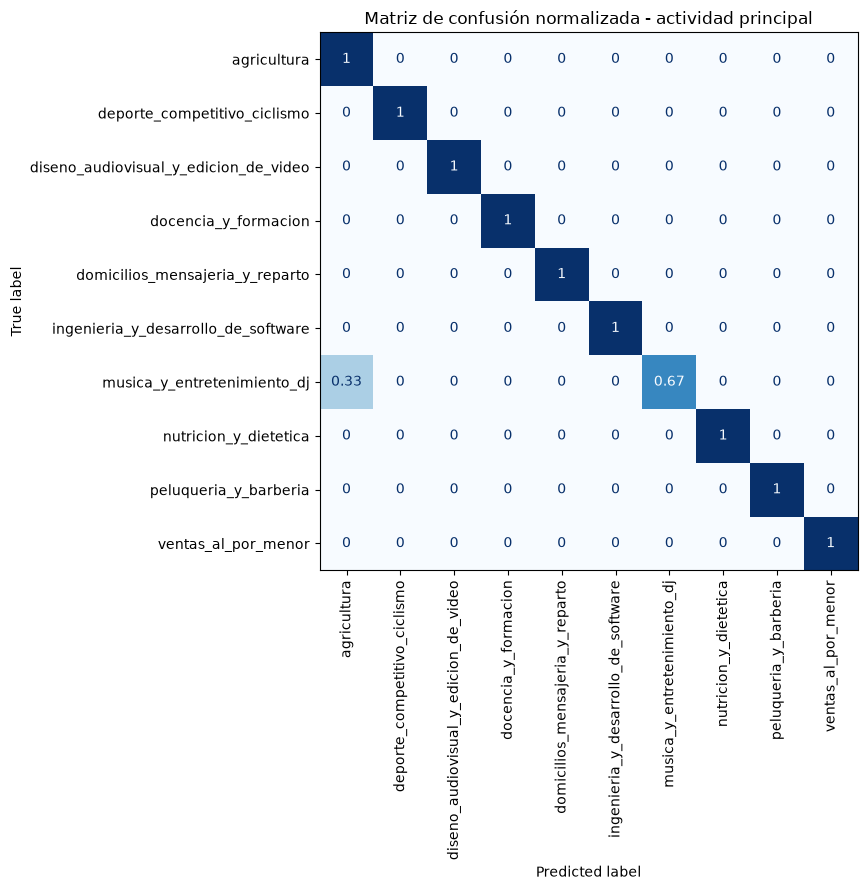

In [43]:
#Matriz de confusión
figura, eje = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    labels=sorted(y_test.unique()),
    normalize='true',
    xticks_rotation=90,
    cmap='Blues',
    ax=eje,
    colorbar=False,
)
eje.set_title('Matriz de confusión normalizada - actividad principal')
plt.tight_layout()
plt.show()

## 8. Contexto declarado adicional

In [44]:
#Preparar objetivos
datos_modelo['actividad_2_objetivo'] = datos_modelo['actividad_2_familia'].fillna('no_declarada')
datos_modelo['meta_objetivo'] = datos_modelo['meta_declarada'].fillna('no_declarada')
datos_modelo['responsabilidad_objetivo'] = datos_modelo['responsabilidad_declarada'].fillna('no_declarada')

datos_modelo['hobbies_objetivo'] = datos_modelo.apply(
    lambda fila: [
        valor
        for valor in [fila['hobby_1'], fila['hobby_2']]
        if pd.notna(valor) and str(valor).strip()
    ],
    axis=1,
)

mapa_ocupacion = catalogo_actividades.set_index('actividad_1_familia')['actividad_1_ocupacion_cuoc'].to_dict()
mapa_codigo_cuoc = catalogo_actividades.set_index('actividad_1_familia')['actividad_1_codigo_cuoc'].to_dict()
mapa_modalidad = datos_modelo.groupby('actividad_1_familia')['actividad_1_modalidad_ingreso'].agg(
    lambda serie: serie.mode().iat[0]
).to_dict()

In [45]:
#Entrenar contexto
objetivos_contexto = {
    'actividad_secundaria': 'actividad_2_objetivo',
    'meta': 'meta_objetivo',
    'responsabilidad': 'responsabilidad_objetivo',
}

modelos_contexto = {}
metricas_contexto = []

for nombre, columna_objetivo in objetivos_contexto.items():
    modelo = crear_pipeline(LogisticRegression(
        C=12.0,
        max_iter=4000,
        class_weight='balanced',
        random_state=SEMILLA,
    ))
    modelo.fit(X_train, datos_modelo.loc[mascara_train, columna_objetivo])
    prediccion_validation = modelo.predict(X_validation)
    prediccion_test_contexto = modelo.predict(X_test)
    modelos_contexto[nombre] = modelo
    metricas_contexto.append({
        'componente': nombre,
        'f1_macro_validation': f1_score(
            datos_modelo.loc[mascara_validation, columna_objetivo],
            prediccion_validation,
            average='macro',
            zero_division=0,
        ),
        'f1_macro_test': f1_score(
            datos_modelo.loc[mascara_test, columna_objetivo],
            prediccion_test_contexto,
            average='macro',
            zero_division=0,
        ),
    })

display(pd.DataFrame(metricas_contexto))

,componente,f1_macro_validation,f1_macro_test
0,actividad_secundaria,0.154545,0.169935
1,meta,1.000000,1.000000
2,responsabilidad,1.000000,1.000000


In [46]:
#Entrenar hobbies
codificador_hobbies = MultiLabelBinarizer(classes=catalogo_hobbies)
codificador_hobbies.fit([catalogo_hobbies])
y_hobbies = codificador_hobbies.transform(datos_modelo['hobbies_objetivo'])

modelo_hobbies = crear_pipeline(OneVsRestClassifier(LogisticRegression(
    C=12.0,
    max_iter=4000,
    class_weight='balanced',
    random_state=SEMILLA,
)))
modelo_hobbies.fit(X_train, y_hobbies[mascara_train.to_numpy()])

probabilidades_hobbies_validation = modelo_hobbies.predict_proba(X_validation)
umbrales_hobbies = np.arange(0.25, 0.76, 0.05)
resultados_umbrales = []

for umbral in umbrales_hobbies:
    prediccion = probabilidades_hobbies_validation >= umbral
    resultados_umbrales.append({
        'umbral': round(float(umbral), 2),
        'f1_macro_validation': f1_score(
            y_hobbies[mascara_validation.to_numpy()],
            prediccion,
            average='macro',
            zero_division=0,
        ),
    })

resultados_umbrales = pd.DataFrame(resultados_umbrales)
UMBRAL_HOBBIES = float(
    resultados_umbrales.sort_values(
        ['f1_macro_validation', 'umbral'],
        ascending=[False, True],
    ).iloc[0]['umbral']
)

prediccion_hobbies_test = modelo_hobbies.predict_proba(X_test) >= UMBRAL_HOBBIES
f1_hobbies_test = f1_score(
    y_hobbies[mascara_test.to_numpy()],
    prediccion_hobbies_test,
    average='macro',
    zero_division=0,
)

display(resultados_umbrales)
print(f'Umbral hobbies: {UMBRAL_HOBBIES:.2f}')
print(f'F1 macro hobbies en test: {f1_hobbies_test:.4f}')

,umbral,f1_macro_validation
0,0.25,0.863993
1,0.30,0.885885
2,0.35,0.898931
3,0.40,0.898931
4,0.45,0.898931
5,0.50,0.898931
6,0.55,0.896550
7,0.60,0.872611
8,0.65,0.805036
9,0.70,0.793131


Umbral hobbies: 0.35
F1 macro hobbies en test: 0.8361


## 9. Función de conocimiento del usuario

In [47]:
#Definir inferencia
def obtener_prediccion(modelo, texto):
    probabilidades = modelo.predict_proba([texto])[0]
    posicion = int(np.argmax(probabilidades))
    return modelo.classes_[posicion], float(probabilidades[posicion])


def clasificar_usuario(descripcion_usuario, umbral_alcance=UMBRAL_ALCANCE):
    if not isinstance(descripcion_usuario, str) or not descripcion_usuario.strip():
        raise ValueError('descripcion_usuario debe contener texto')

    texto = descripcion_usuario.strip()
    probabilidades = modelo_actividad.predict_proba([texto])[0]
    orden = np.argsort(probabilidades)[::-1]
    actividad_principal = modelo_actividad.classes_[orden[0]]
    confianza_principal = float(probabilidades[orden[0]])
    top_3_actividades = [
        {
            'actividad': modelo_actividad.classes_[posicion],
            'porcentaje': round(float(probabilidades[posicion]) * 100, 2),
        }
        for posicion in orden[:3]
    ]

    if confianza_principal < umbral_alcance:
        return {
            'descripcion_usuario': texto,
            'estado_alcance_mvp': 'no_disponible',
            'actividad_principal': 'no_disponible',
            'confianza_actividad_pct': round(confianza_principal * 100, 2),
            'actividad_secundaria': 'no_clasificada',
            'modalidad_ingreso_principal': 'no_clasificada',
            'hobbies_intereses': ['no_clasificados'],
            'meta': 'no_clasificada',
            'responsabilidad': 'no_clasificada',
            'top_3_actividades': top_3_actividades,
            'motivo': 'La actividad principal no alcanzó el 50% de confianza dentro del catálogo del MVP',
            'version_modelo': VERSION_MODELO,
        }

    actividad_secundaria, confianza_secundaria = obtener_prediccion(
        modelos_contexto['actividad_secundaria'],
        texto,
    )
    meta, confianza_meta = obtener_prediccion(modelos_contexto['meta'], texto)
    responsabilidad, confianza_responsabilidad = obtener_prediccion(
        modelos_contexto['responsabilidad'],
        texto,
    )

    if confianza_secundaria < UMBRAL_ALCANCE:
        actividad_secundaria = 'no_declarada'
    if confianza_meta < UMBRAL_ALCANCE:
        meta = 'no_declarada'
    if confianza_responsabilidad < UMBRAL_ALCANCE:
        responsabilidad = 'no_declarada'

    probabilidades_hobbies = modelo_hobbies.predict_proba([texto])[0]
    posiciones_hobbies = np.flatnonzero(probabilidades_hobbies >= UMBRAL_HOBBIES)
    hobbies = [codificador_hobbies.classes_[posicion] for posicion in posiciones_hobbies]

    return {
        'descripcion_usuario': texto,
        'estado_alcance_mvp': 'dentro_del_mvp',
        'actividad_principal': actividad_principal,
        'ocupacion_cuoc': mapa_ocupacion.get(actividad_principal, 'no_disponible'),
        'codigo_cuoc': mapa_codigo_cuoc.get(actividad_principal, 'no_disponible'),
        'confianza_actividad_pct': round(confianza_principal * 100, 2),
        'actividad_secundaria': actividad_secundaria,
        'modalidad_ingreso_principal': mapa_modalidad.get(actividad_principal, 'no_disponible'),
        'fuente_modalidad': 'inferencia_catalogo_mvp',
        'hobbies_intereses': hobbies if hobbies else ['no_declarado'],
        'meta': meta,
        'responsabilidad': responsabilidad,
        'top_3_actividades': top_3_actividades,
        'motivo': 'Actividad principal reconocida dentro del catálogo cerrado del MVP',
        'version_modelo': VERSION_MODELO,
    }

## 10. Serialización

In [48]:
#Guardar modelo
ruta_modelos = ruta_proyecto / 'Modelos'
ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_artefacto = ruta_modelos / '01_conocimiento_usuario.joblib'

artefacto_usuario = {
    'version_modelo': VERSION_MODELO,
    'modelo_actividad': modelo_actividad,
    'nombre_modelo_actividad': nombre_modelo_actividad,
    'modelos_contexto': modelos_contexto,
    'modelo_hobbies': modelo_hobbies,
    'codificador_hobbies': codificador_hobbies,
    'mapa_ocupacion': mapa_ocupacion,
    'mapa_codigo_cuoc': mapa_codigo_cuoc,
    'mapa_modalidad': mapa_modalidad,
    'umbral_alcance': UMBRAL_ALCANCE,
    'umbral_hobbies': UMBRAL_HOBBIES,
    'version_esquema': sorted(datos_modelo['version_esquema'].dropna().unique().tolist()),
}

joblib.dump(artefacto_usuario, ruta_artefacto)
print(f'Modelo guardado en: {ruta_artefacto}')

Modelo guardado en: /Users/jeis/Documents/esc/Proyectos/hackaton/Modelos/01_conocimiento_usuario.joblib


## 11. Pruebas manuales

In [52]:
#Casos dentro del MVP
test_clasificables = [
    {
        'descripcion_usuario': 'Trabajo como ingeniero de software. En mi tiempo libre disfruto ciclismo. Quiero comprar equipo de trabajo.',
        'actividad_esperada': 'ingenieria_y_desarrollo_de_software',
    },
    {
        'descripcion_usuario': 'Trabajo como nutricionista dietista. En mi tiempo libre disfruto la cocina, reposteria, fotografia y video. Quiero ampliar mi actividad economica.',
        'actividad_esperada': 'nutricion_y_dietetica',
    },
    {
        'descripcion_usuario': 'Trabajo como repartidor de domicilios. Tambien genero ingresos como vendedor enn una tienda. En mi tiempo libre disfruto del ciclismo.',
        'actividad_esperada': 'domicilios_mensajeria_y_reparto',
    },
]

resultados_clasificables = []

for caso in test_clasificables:
    resultado = clasificar_usuario(caso['descripcion_usuario'])
    resultado['actividad_esperada'] = caso['actividad_esperada']
    resultado['cumple_esperado'] = (
        resultado['estado_alcance_mvp'] == 'dentro_del_mvp'
        and resultado['actividad_principal'] == caso['actividad_esperada']
    )
    resultados_clasificables.append(resultado)

columnas_resultado = [
    'descripcion_usuario',
    'estado_alcance_mvp',
    'actividad_principal',
    'actividad_esperada',
    'confianza_actividad_pct',
    'actividad_secundaria',
    'modalidad_ingreso_principal',
    'hobbies_intereses',
    'meta',
    'responsabilidad',
    'top_3_actividades',
    'cumple_esperado',
]

display(pd.DataFrame(resultados_clasificables)[columnas_resultado])

,descripcion_usuario,estado_alcance_mvp,actividad_principal,actividad_esperada,confianza_actividad_pct,actividad_secundaria,modalidad_ingreso_principal,hobbies_intereses,meta,responsabilidad,top_3_actividades,cumple_esperado
0,Trabajo como ingeniero de software. En mi tiem...,dentro_del_mvp,ingenieria_y_desarrollo_de_software,ingenieria_y_desarrollo_de_software,80.86,no_declarada,mixto,"[ciclismo, pintura]",comprar_equipo_de_trabajo,no_declarada,[{'actividad': 'ingenieria_y_desarrollo_de_sof...,True
1,Trabajo como nutricionista dietista. En mi tie...,dentro_del_mvp,nutricion_y_dietetica,nutricion_y_dietetica,87.75,docencia_y_formacion,mixto,"[cocina_y_reposteria, fotografia_y_video]",ampliar_actividad_economica,no_declarada,"[{'actividad': 'nutricion_y_dietetica', 'porce...",True
2,Trabajo como repartidor de domicilios. Tambien...,dentro_del_mvp,domicilios_mensajeria_y_reparto,domicilios_mensajeria_y_reparto,51.67,ventas_al_por_menor,variable,"[ciclismo, fotografia_y_video]",no_declarada,no_declarada,[{'actividad': 'domicilios_mensajeria_y_repart...,True


In [50]:
#Caso fuera del MVP
test_no_clasificable = {
    'descripcion_usuario': 'Trabajo como mecanico automotriz y reparo vehiculos. En mi tiempo libre disfruto natacion.',
    'salida_esperada': 'no_disponible',
}

resultado_no_clasificable = clasificar_usuario(test_no_clasificable['descripcion_usuario'])
resultado_no_clasificable['salida_esperada'] = test_no_clasificable['salida_esperada']
resultado_no_clasificable['cumple_esperado'] = (
    resultado_no_clasificable['estado_alcance_mvp'] == test_no_clasificable['salida_esperada']
    and resultado_no_clasificable['actividad_principal'] == test_no_clasificable['salida_esperada']
)

display(pd.DataFrame([resultado_no_clasificable]))

,descripcion_usuario,estado_alcance_mvp,actividad_principal,confianza_actividad_pct,actividad_secundaria,modalidad_ingreso_principal,hobbies_intereses,meta,responsabilidad,top_3_actividades,motivo,version_modelo,salida_esperada,cumple_esperado
0,Trabajo como mecanico automotriz y reparo vehi...,no_disponible,no_disponible,22.04,no_clasificada,no_clasificada,[no_clasificados],no_clasificada,no_clasificada,[{'actividad': 'domicilios_mensajeria_y_repart...,La actividad principal no alcanzó el 50% de co...,fincoach_usuario_mvp_v1,no_disponible,True
